# Summary
This notebook trains a ResNet9 convolutional neural network (with PyTorch) to classify CIFAR-10 images into 10 classes, including data augmentation, GPU training, and one-cycle-style hyperparameter tuning.

## Imports
We use PyTorch and torchvision to build, train, and evaluate the CNN, plus Matplotlib for visualization.

In [1]:
import os
import torch
import torchvision
import tarfile
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torchvision.datasets.utils import download_url
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torch.utils.data import random_split
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline

project_name='05b-cifar10-resnet'


## Download the CIFAR-10 dataset
We download the CIFAR-10 dataset (already split into `train` and `test` folders, one subfolder per class) and extract it locally.

In [2]:
# Dowload the dataset
dataset_url = "http://files.fast.ai/data/examples/cifar10.tgz"

# Uncomment code for download and extract data the first time you run the code
#download_url(dataset_url, '.')
# Extract from archive
#with tarfile.open('./cifar10.tgz', 'r:gz') as tar:
#    tar.extractall(path='./data')
    
# Look into the data directory
data_dir = './data/cifar10'
print(os.listdir(data_dir))
classes = os.listdir(data_dir + "/train")
print(classes)

['train', 'test', 'labels.txt']
['frog', 'airplane', 'horse', 'truck', 'cat', 'deer', 'automobile', 'dog', 'bird', 'ship']


## Data augmentation, normalization, and data loaders
We normalize images using per-channel statistics and apply random cropping and horizontal flipping to the training set for data augmentation. `DataLoader` objects then serve shuffled batches of images during training.

In [3]:
# Data transforms (normalization & data augmentation)
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
train_tfms = tt.Compose([tt.RandomCrop(32, padding=4, padding_mode='reflect'), 
                         tt.RandomHorizontalFlip(), 
                         tt.ToTensor(), 
                         tt.Normalize(*stats,inplace=True)])
valid_tfms = tt.Compose([tt.ToTensor(), tt.Normalize(*stats)])

# PyTorch datasets
train_ds = ImageFolder(data_dir+'/train', train_tfms)
valid_ds = ImageFolder(data_dir+'/test', valid_tfms)

batch_size = 400


# PyTorch data loaders
train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)
valid_dl = DataLoader(valid_ds, batch_size*2, num_workers=3, pin_memory=True)

## Visualize a training batch
We display a grid of images from one training batch to sanity-check the data and the augmentations.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4290657..2.7537313].


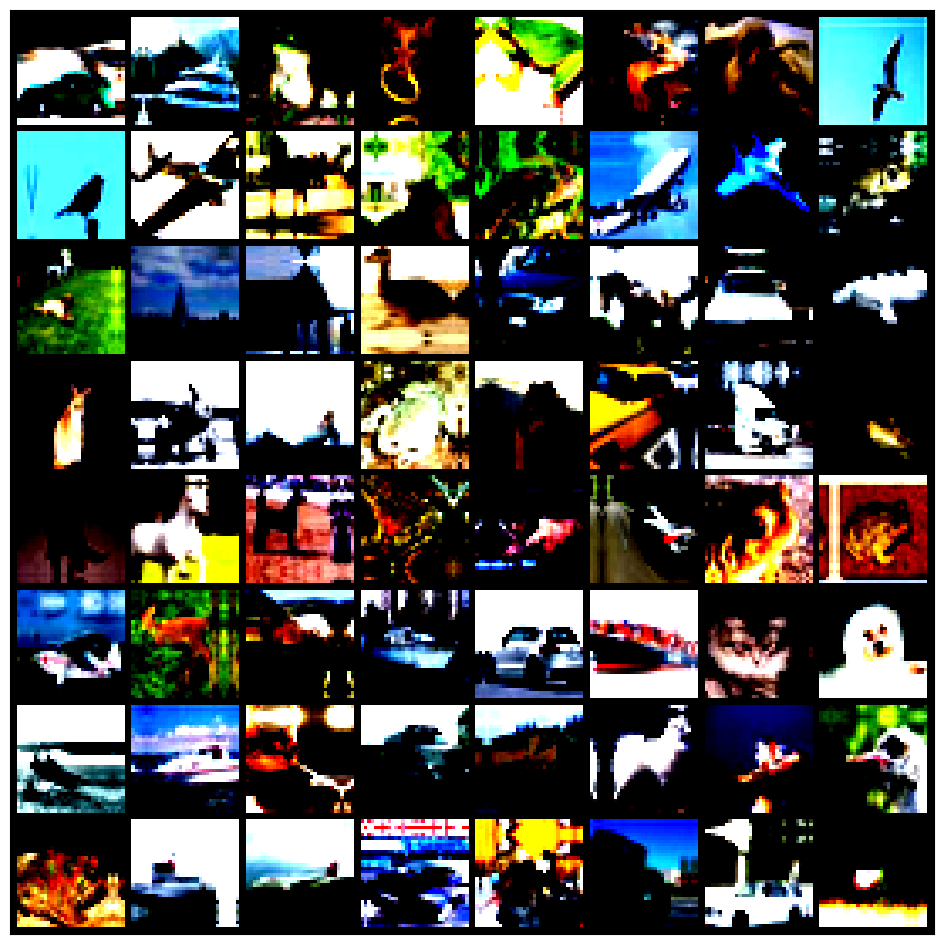

In [4]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images[:64], nrow=8).permute(1, 2, 0))
        break
        
show_batch(train_dl)



## Move data and model to the GPU
These helper functions and the `DeviceDataLoader` wrapper move tensors (and whole batches) to the GPU when one is available, falling back to the CPU otherwise.

In [5]:
# GPU functions

def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)
    
device = get_default_device()
device

train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(valid_dl, device)

## Residual block sanity check
A residual block applies two convolution + ReLU layers and adds the input back to the output. We instantiate one and run it on a single batch to check that the output shape matches the input shape.

In [6]:
class SimpleResidualBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        
    def forward(self, x):
        out = self.conv1(x)
        out = self.relu1(out)
        out = self.conv2(out)
        return self.relu2(out) + x # ReLU can be applied before or after adding the input
    
simple_resnet = to_device(SimpleResidualBlock(), device)

for images, labels in train_dl:
    out = simple_resnet(images)
    print(out.shape)
    break
    
del simple_resnet, images, labels
torch.cuda.empty_cache()

torch.Size([400, 3, 32, 32])


## Base training/evaluation utilities
The `accuracy` function compares predictions to labels. `ImageClassificationBase` provides shared `training_step`, `validation_step`, and epoch-end logic that any classification model can inherit.

In [7]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'], result['val_acc']))

## ResNet9 architecture
`conv_block` builds a Conv2d + BatchNorm + ReLU block, optionally followed by max pooling. `ResNet9` stacks these blocks and adds two residual blocks (`res1`, `res2`), each adding its input back to its output, followed by a classifier head.

In [8]:
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1), 
              nn.BatchNorm2d(out_channels), 
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(ImageClassificationBase):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))
        
        self.classifier = nn.Sequential(nn.MaxPool2d(4), 
                                        nn.Flatten(), 
                                        nn.Linear(512, num_classes))
        
    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out
        out = self.classifier(out)
        return out
    
model = to_device(ResNet9(3, 10), device)
model

ResNet9(
  (conv1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (res1): Sequential(
    (0): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=Tr

## Training and evaluation loop
`evaluate` runs the model in evaluation mode over the validation set. `fit_one_cycle` trains the model for a number of epochs, recording the training loss, gradient norm, and learning rate at each step. We also evaluate the untrained model once to get a baseline.

In [9]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader, 
                  weight_decay=0, grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []
        
    # Set up cutom optimizer with weight decay
    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    # Set up one-cycle learning rate scheduler
    #sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, 
    #                                            steps_per_epoch=len(train_loader))
    
    for epoch in range(epochs):
        # Training Phase 
        model.train()
        grad_norm = []
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            
            # Gradient clipping
            if grad_clip: 
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)
            
            optimizer.step()
            
            # Record & update learning rate
            lrs.append(get_lr(optimizer))
            #sched.step()
            optimizer.step()
            
            # Record gradient norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
                else:
                    print("Error: No gradient!")
            total_norm = total_norm ** (1. / 2)
            #total_norm = np.sqrt(sum([torch.norm(p.grad)**2 for p in model.parameters()]))
            grad_norm.append(total_norm)
            
            optimizer.zero_grad()
        
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        result['grad_norm'] = grad_norm
        #print(grad_norm)
        model.epoch_end(epoch, result)
        history.append(result)
    return history

history = [evaluate(model, valid_dl)]
history

[{'val_loss': 2.3040246963500977, 'val_acc': 0.09615384787321091}]

## Hyperparameters
We set the number of epochs, the maximum learning rate, gradient clipping value, weight decay, and the optimizer used for training.

In [10]:
epochs = 10
max_lr = 0.0025
grad_clip = None # No gradient clipping, set to a value to activate gradient clipping, e.g. grad_clip = 0.1
weight_decay = 0 # 1e-4
opt_func = torch.optim.Adam # another option would be torch.optim.SGD

## Train the model
We train the model for the chosen number of epochs, recording the training/validation loss, accuracy, gradient norm, and learning rate at each step.

In [11]:
%%time
history += fit_one_cycle(epochs, max_lr, model, train_dl, valid_dl, 
                             grad_clip=grad_clip, 
                             weight_decay=weight_decay, 
                             opt_func=opt_func)

Epoch [0], last_lr: 0.00250, train_loss: 2.2091, val_loss: 1.7655, val_acc: 0.4246
Epoch [1], last_lr: 0.00250, train_loss: 1.3918, val_loss: 1.2517, val_acc: 0.5734
Epoch [2], last_lr: 0.00250, train_loss: 1.0993, val_loss: 1.0051, val_acc: 0.6638
Epoch [3], last_lr: 0.00250, train_loss: 0.8820, val_loss: 0.8345, val_acc: 0.7135
Epoch [4], last_lr: 0.00250, train_loss: 0.7351, val_loss: 0.8575, val_acc: 0.7065
Epoch [5], last_lr: 0.00250, train_loss: 0.6200, val_loss: 0.6920, val_acc: 0.7559
Epoch [6], last_lr: 0.00250, train_loss: 0.5525, val_loss: 0.6861, val_acc: 0.7753
Epoch [7], last_lr: 0.00250, train_loss: 0.4802, val_loss: 0.5295, val_acc: 0.8246
Epoch [8], last_lr: 0.00250, train_loss: 0.4385, val_loss: 0.5801, val_acc: 0.8166
Epoch [9], last_lr: 0.00250, train_loss: 0.3828, val_loss: 0.5798, val_acc: 0.8108
CPU times: user 2min 50s, sys: 3.91 s, total: 2min 53s
Wall time: 3min 2s


## Plot validation accuracy
We plot how the validation accuracy evolves across epochs.

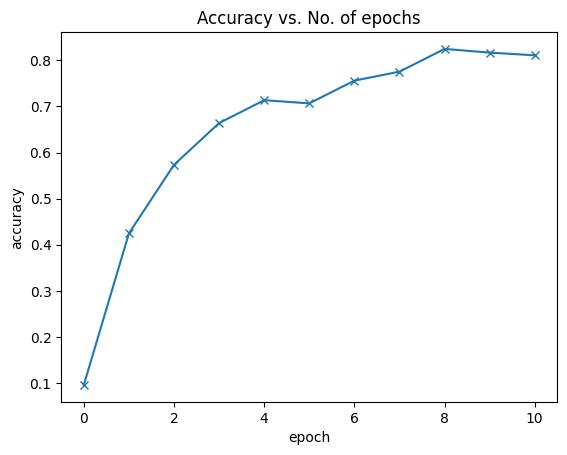

In [12]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');
    
plot_accuracies(history)


## Plot gradient norms
We plot the L2 norm of the gradients recorded during the first training epoch to monitor training stability.

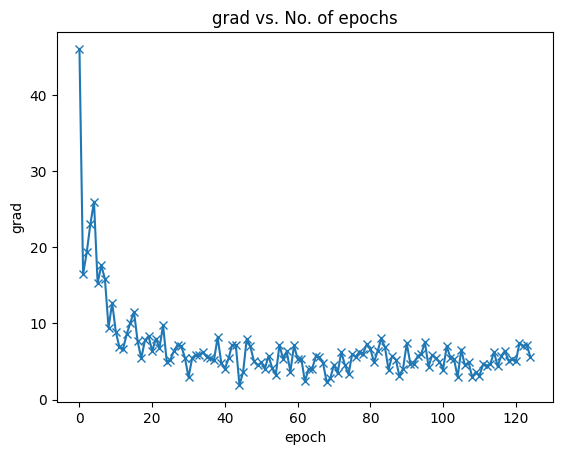

In [13]:
def plot_gradients(history):
    #accuracies = [x['grad_norm'] for x in history]
    grad = [x.get('grad_norm') for x in history][1]
    #print(accuracies)
    plt.plot(grad, '-x')
    plt.xlabel('epoch')
    plt.ylabel('grad')
    plt.title('grad vs. No. of epochs');
    
plot_gradients(history)

## Plot training and validation loss
We plot the training and validation loss together to check for overfitting or underfitting.

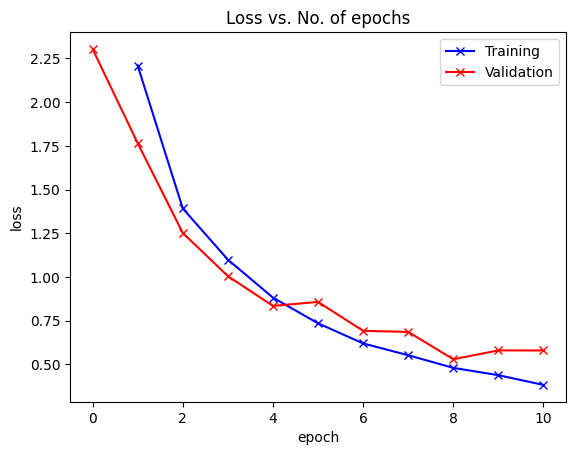

In [14]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');
    
plot_losses(history)


## Save the trained model
Finally, we save the trained model's parameters to disk so they can be reloaded later.

In [16]:
torch.save(model.state_dict(), 'cifar10-resnet9.pth')


## Inspect random predictions
We pick `m * n` random images from the validation set, run them through the trained model, and display them in a grid alongside their predicted and actual class.

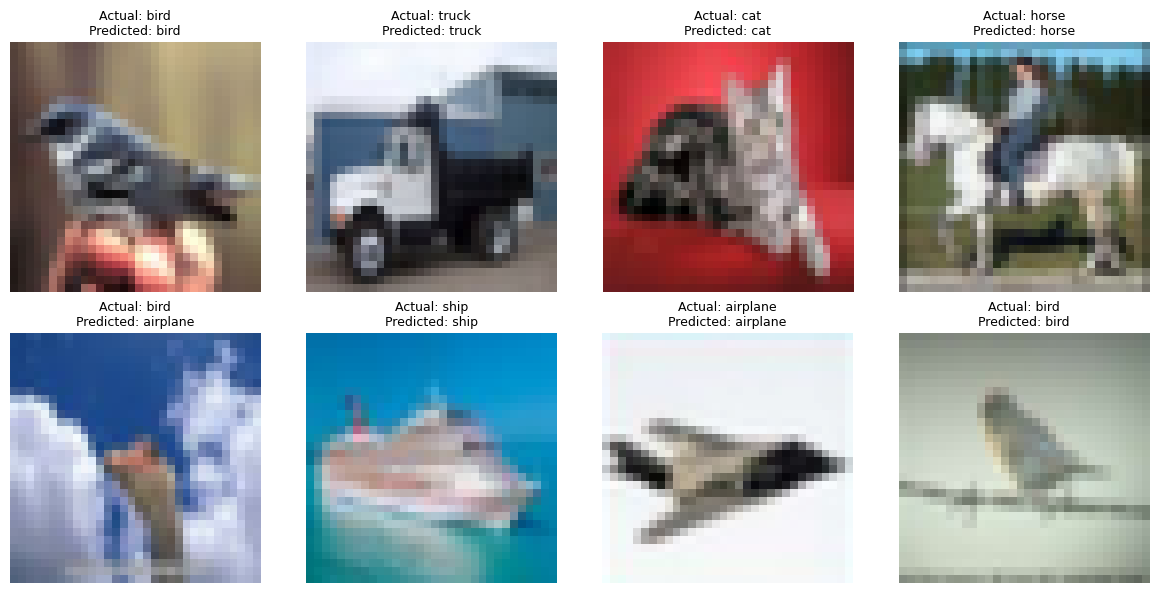

In [20]:
import random

def predict_image(img, model):
    xb = to_device(img.unsqueeze(0), device)
    yb = model(xb)
    _, preds = torch.max(yb, dim=1)
    return valid_ds.classes[preds[0].item()]

def denormalize(img_tensor, means, stds):
    means = torch.tensor(means).reshape(3, 1, 1)
    stds = torch.tensor(stds).reshape(3, 1, 1)
    return img_tensor * stds + means

m, n = 2, 4  # grid rows, columns

fig, axes = plt.subplots(m, n, figsize=(3 * n, 3 * m))

for ax in axes.flat:
    idx = random.randint(0, len(valid_ds) - 1)
    img, label = valid_ds[idx]
    pred = predict_image(img, model)

    ax.imshow(denormalize(img, *stats).permute(1, 2, 0).clamp(0, 1))
    ax.set_title(f'Actual: {valid_ds.classes[label]}\nPredicted: {pred}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()